<a href="https://colab.research.google.com/github/austinmallie/ADS599_Capstone/blob/main/EDA/hospital_ransomware_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comprehensive EDA: `hospital_ransomware_master.csv`

This is an EDA based on all three data sources being Breach data, Hospital General Information and Hospital Cost Report

In [ ]:
from google.colab import userdata
import os

token    = userdata.get('GitHub')
owner    = "austinmallie"
repo     = "ADS599_Capstone"
repo_url = f"https://{token}@github.com/{owner}/{repo}.git"

# Only clone if the folder doesn't exist already
if not os.path.exists(repo):
    !git clone {repo_url}
else:
    print("Repo already cloned. Pulling latest changes...")
    %cd {repo}
    !git pull

%cd /content/{repo}

Cloning into 'ADS599_Capstone'...
remote: Enumerating objects: 333, done.
remote: Counting objects: 100% (194/194), done.
remote: Compressing objects: 100% (174/174), done.
remote: Total 333 (delta 105), reused 25 (delta 18), pack-reused 139 (from 1)
Receiving objects: 100% (333/333), 50.38 MiB | 11.62 MiB/s, done.
Resolving deltas: 100% (119/119), done.
/content/ADS599_Capstone


In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

repo_base_path = '/content/ADS599_Capstone'

# Define the full path to the parquet file
file_path = os.path.join(repo_base_path, 'Models', 'hospital_ransomware_model.parquet')

# Load the parquet file into a pandas DataFrame
try:
    df_model = pd.read_parquet(file_path)
    print(f"Successfully loaded file from: {file_path}")
    df = df_model.copy()
    # Display the first 5 rows of the DataFrame
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file {file_path} was not found. Please ensure the repository is cloned and the file exists at the specified path.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded file from: /content/ADS599_Capstone/Models/hospital_ransomware_model.parquet


,ccn,cbsa,fte_employees,beds,total_discharges,total_unreimbursed_and_uncompensated_care,total_costs,cash_on_hand_and_in_banks,total_assets,total_liabilities,...,mort_worse,safety_better,safety_worse,readm_better,readm_worse,net_performance_score,net_performance_rate,performance_ratio,total_individuals_affected,had_ransomware
0,10001,20020.0,2405.80,398.0,18489.0,28691031.0,231992999.0,5836798.0,393203543.0,155249153.0,...,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0.0,0
1,10001,20020.0,2379.50,400.0,18484.0,25026782.0,238867113.0,8339540.0,391583329.0,152831940.0,...,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0.0,0
2,10001,20020.0,2397.43,387.0,19632.0,29216156.0,246974731.0,6085744.0,383657576.0,142863228.0,...,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0.0,0
3,10001,20020.0,2425.37,387.0,19677.0,21713434.0,250424328.0,31651152.0,391259641.0,140218773.0,...,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0.0,0
4,10001,20020.0,2371.67,327.0,19963.0,21782404.0,262391792.0,32282079.0,390435696.0,146622307.0,...,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0.0,0


## 1. Dataset overview

In [ ]:
display(df.head())
display(df.sample(5, random_state=42))


,ccn,cbsa,fte_employees,beds,total_discharges,total_unreimbursed_and_uncompensated_care,total_costs,cash_on_hand_and_in_banks,total_assets,total_liabilities,...,mort_worse,safety_better,safety_worse,readm_better,readm_worse,net_performance_score,net_performance_rate,performance_ratio,total_individuals_affected,had_ransomware
0,10001,20020.0,2405.80,398.0,18489.0,28691031.0,231992999.0,5836798.0,393203543.0,155249153.0,...,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0.0,0
1,10001,20020.0,2379.50,400.0,18484.0,25026782.0,238867113.0,8339540.0,391583329.0,152831940.0,...,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0.0,0
2,10001,20020.0,2397.43,387.0,19632.0,29216156.0,246974731.0,6085744.0,383657576.0,142863228.0,...,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0.0,0
3,10001,20020.0,2425.37,387.0,19677.0,21713434.0,250424328.0,31651152.0,391259641.0,140218773.0,...,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0.0,0
4,10001,20020.0,2371.67,327.0,19963.0,21782404.0,262391792.0,32282079.0,390435696.0,146622307.0,...,0.0,0.428571,0.0,0.0,0.0,3.0,0.12,0.12,0.0,0


,ccn,cbsa,fte_employees,beds,total_discharges,total_unreimbursed_and_uncompensated_care,total_costs,cash_on_hand_and_in_banks,total_assets,total_liabilities,...,mort_worse,safety_better,safety_worse,readm_better,readm_worse,net_performance_score,net_performance_rate,performance_ratio,total_individuals_affected,had_ransomware
58926,520096,39540.0,1007.11,285.0,7709.0,19642425.0,253648933.0,9741.0,293804799.0,65899432.0,...,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.000000,0.000000,0.0,0
38219,340064,99934.0,521.13,93.0,3609.0,7906693.0,71913402.0,10711162.0,83847501.0,31843639.0,...,0.0,0.000000,0.000000,0.125,0.000000,1.0,0.058824,0.058824,0.0,0
12957,110198,12060.0,592.00,169.0,6654.0,13894655.0,138173195.0,1300.0,216898990.0,95198386.0,...,0.0,0.333333,0.166667,0.000,0.142857,0.0,0.000000,0.105263,0.0,0
2969,40134,30780.0,685.63,112.0,4517.0,4596429.0,111716469.0,3638319.0,111010016.0,76330418.0,...,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.000000,0.000000,0.0,0
51060,450299,17780.0,488.12,152.0,4134.0,5592128.0,79295571.0,-722294.0,89193435.0,9851101.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0


In [ ]:
overview = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "unique hospitals (ccn)",
        "report_year min",
        "report_year max",
        "numeric columns",
        "non-numeric columns"
    ],
    "value": [
        len(df),
        df.shape[1],
        df["ccn"].nunique() if "ccn" in df.columns else np.nan,
        df["report_year"].min() if "report_year" in df.columns else np.nan,
        df["report_year"].max() if "report_year" in df.columns else np.nan,
        df.select_dtypes(include=np.number).shape[1],
        df.select_dtypes(exclude=np.number).shape[1]
    ]
})
display(overview)

dtype_summary = df.dtypes.astype(str).value_counts().rename_axis("dtype").reset_index(name="count")
display(dtype_summary)

,metric,value
0,rows,61444
1,columns,64
2,unique hospitals (ccn),6804
3,report_year min,2014
4,report_year max,2023
5,numeric columns,60
6,non-numeric columns,4


,dtype,count
0,float64,55
1,int64,5
2,category,2
3,object,2


## 2. Missing-value analysis

,column,missing_pct
0,hospital_rating,55.141267
1,contract_labor_share,48.894929
2,safety_better,47.381355
3,safety_worse,47.381355
4,mort_worse,42.770653
5,mort_better,42.770653
6,readm_better,32.880346
7,readm_worse,32.880346
8,net_performance_rate,32.466962
9,performance_ratio,32.466962


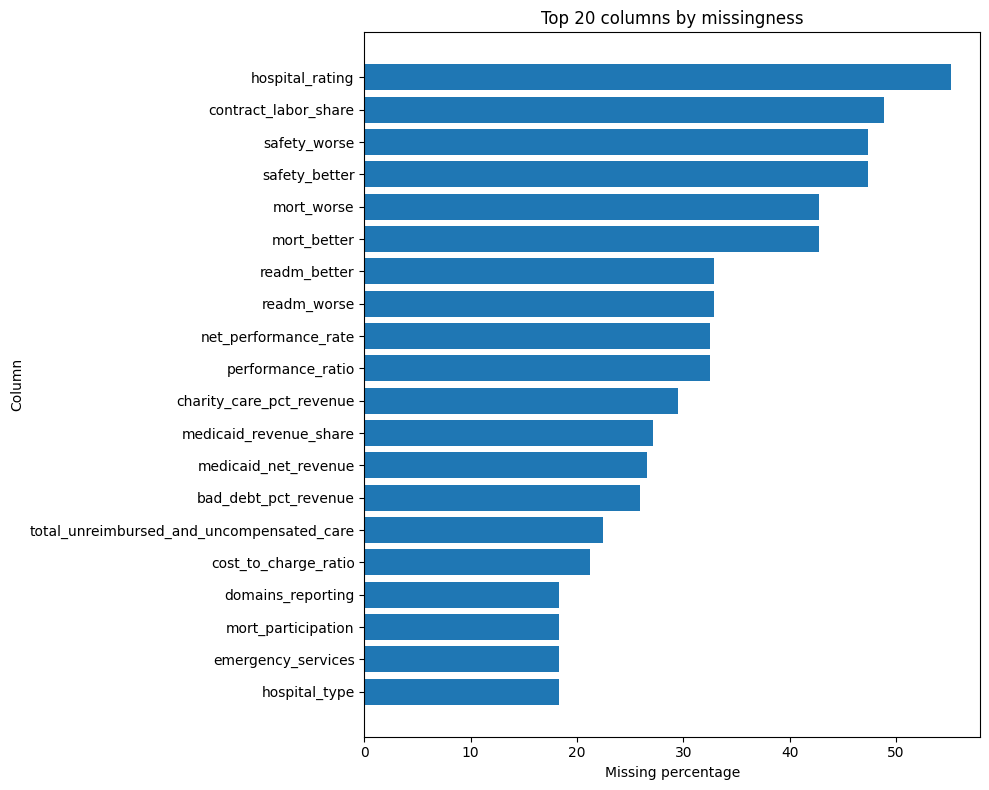

In [ ]:
missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .rename("missing_pct")
      .reset_index()
      .rename(columns={"index": "column"})
)

display(missing.head(20))

top_missing = missing.head(20).sort_values("missing_pct")
plt.figure(figsize=(10, 8))
plt.barh(top_missing["column"], top_missing["missing_pct"])
plt.xlabel("Missing percentage")
plt.ylabel("Column")
plt.title("Top 20 columns by missingness")
plt.tight_layout()
plt.show()


In [ ]:
missing_bands = pd.cut(
    missing["missing_pct"],
    bins=[-0.1, 0, 5, 20, 50, 100],
    labels=["0%", ">0% to 5%", ">5% to 20%", ">20% to 50%", ">50%"]
)
display(missing_bands.value_counts().sort_index().rename("column_count").to_frame())


,column_count
missing_pct,
0%,6
>0% to 5%,19
>5% to 20%,23
>20% to 50%,15
>50%,1


## 3. Duplicate and key-integrity checks

In [ ]:
exact_duplicates = int(df.duplicated().sum())
ccn_year_duplicates = int(df.duplicated(subset=["ccn", "report_year"]).sum()) if {"ccn", "report_year"}.issubset(df.columns) else np.nan

integrity = pd.DataFrame({
    "check": ["exact duplicate rows", "duplicate (ccn, report_year) pairs"],
    "count": [exact_duplicates, ccn_year_duplicates]
})
display(integrity)

if {"ccn", "report_year"}.issubset(df.columns):
    dup_examples = (
        df[df.duplicated(subset=["ccn", "report_year"], keep=False)]
        .sort_values(["ccn", "report_year"])
        .head(10)
    )
    display(dup_examples[["ccn", "report_year"] + [c for c in ["hospital_type", "hospital_ownership", "had_ransomware", "had_breach"] if c in df.columns]])


,check,count
0,exact duplicate rows,15
1,"duplicate (ccn, report_year) pairs",953


,ccn,report_year,hospital_type,hospital_ownership,had_ransomware
46,10008,2020,Acute Care,For-Profit,0
47,10008,2020,Acute Care,For-Profit,0
73,10016,2016,Acute Care,Non-Profit,0
74,10016,2016,Acute Care,Non-Profit,0
93,10019,2015,Acute Care,Government,0
94,10019,2015,Acute Care,Government,0
117,10022,2018,Acute Care,For-Profit,0
118,10022,2018,Acute Care,For-Profit,0
158,10032,2018,None,None,0
159,10032,2018,None,None,0


## 4. Target-variable exploration

,column,mean,sum,non_null
0,had_ransomware,0.029555,1816,61444
1,is_profitable,0.649453,39905,61444
2,high_charity,0.103899,6384,61444


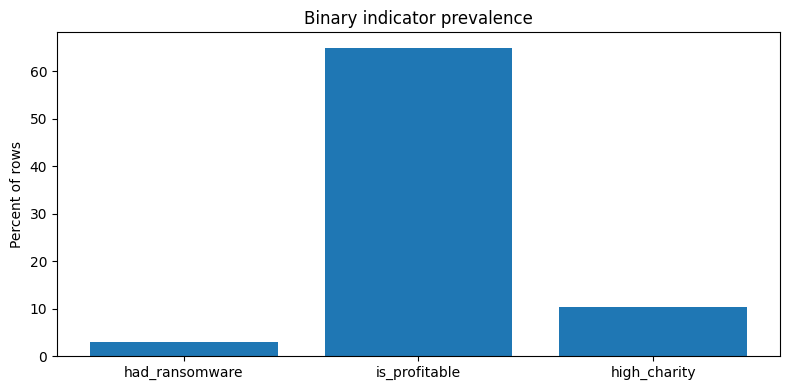

In [ ]:
target_cols = [c for c in ["had_ransomware", "had_breach", "is_profitable", "high_charity"] if c in df.columns]

target_summary = pd.DataFrame({
    "column": target_cols,
    "mean": [df[c].mean() for c in target_cols],
    "sum": [df[c].sum() for c in target_cols],
    "non_null": [df[c].notna().sum() for c in target_cols]
})
display(target_summary)

if target_cols:
    plot_data = target_summary.copy()
    plot_data["mean_pct"] = plot_data["mean"] * 100
    plt.figure(figsize=(8, 4))
    plt.bar(plot_data["column"], plot_data["mean_pct"])
    plt.ylabel("Percent of rows")
    plt.title("Binary indicator prevalence")
    plt.tight_layout()
    plt.show()


In [ ]:
if "report_year" in df.columns and {"had_ransomware", "had_breach"}.issubset(df.columns):
    yearly_rates = df.groupby("report_year")[["had_ransomware", "had_breach"]].mean() * 100
    display(yearly_rates.round(2))

    plt.figure(figsize=(10, 5))
    plt.plot(yearly_rates.index, yearly_rates["had_ransomware"], marker="o", label="had_ransomware")
    plt.plot(yearly_rates.index, yearly_rates["had_breach"], marker="o", label="had_breach")
    plt.ylabel("Rate (%)")
    plt.xlabel("Report year")
    plt.title("Breach/ransomware rate by report year")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 5. Categorical-variable exploration

In [ ]:
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()
categorical_cols


['bed_tier', 'revenue_tier', 'hospital_type', 'hospital_ownership']

In [ ]:
for col in categorical_cols:
    print(f"\n=== {col} ===")
    vc = df[col].value_counts(dropna=False).head(15)
    display(vc.to_frame("count"))



=== bed_tier ===


,count
bed_tier,
Micro,17580
Medium,12133
Major,12068
Large,12054
Small,6748
NaN,861



=== revenue_tier ===


,count
revenue_tier,
Q1_Low,14737
Q2_Mid-Low,14736
Q3_Mid-High,14736
Q4_High,14736
NaN,2499



=== hospital_type ===


,count
hospital_type,
Acute Care,30561
Rural/Access,13304
None,11227
Psychiatric,5433
Childrens,877
Long-term,42



=== hospital_ownership ===


,count
hospital_ownership,
Non-Profit,28527
Government,11366
None,11227
For-Profit,10324


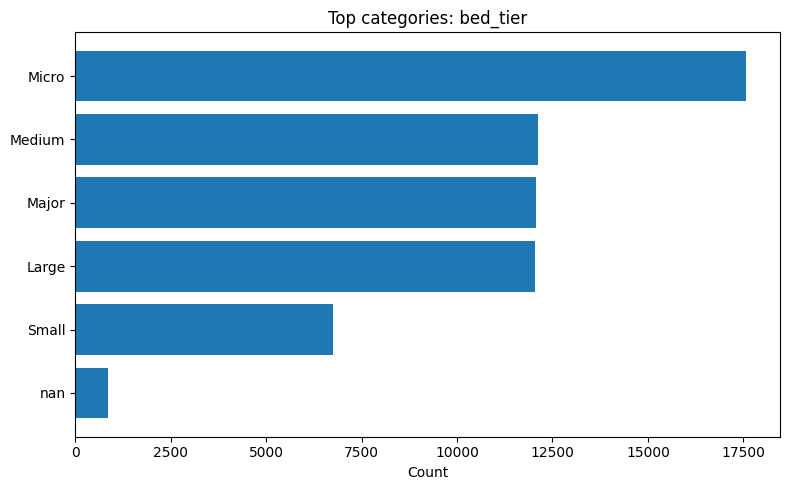

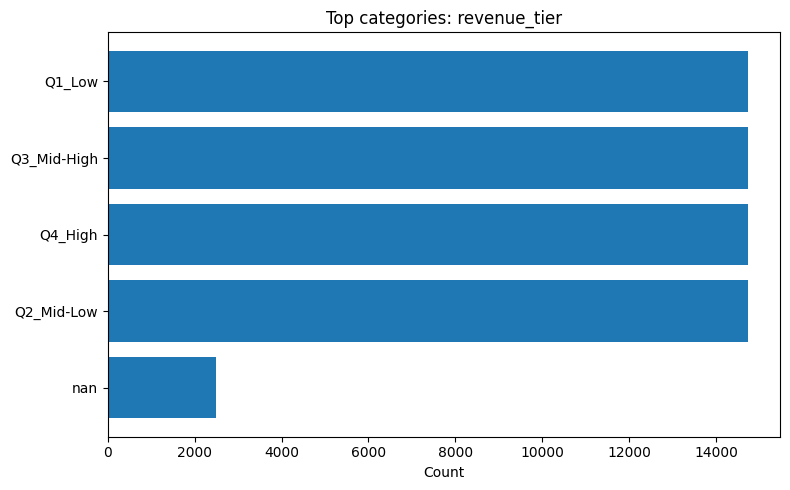

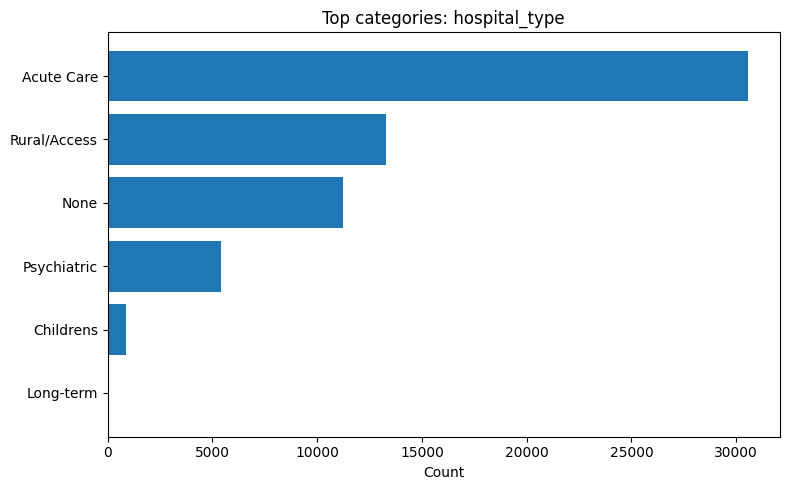

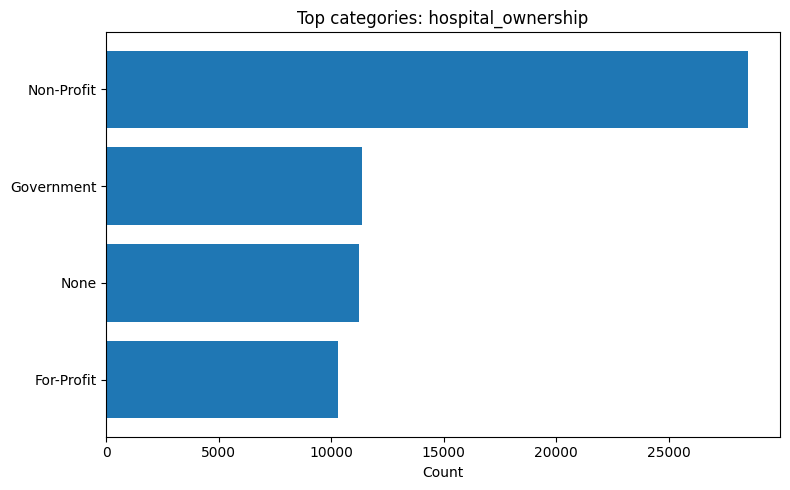

In [ ]:
plot_candidates = [c for c in ["bed_tier", "revenue_tier", "hospital_type", "hospital_ownership"] if c in df.columns]

for col in plot_candidates:
    counts = df[col].value_counts(dropna=False).head(10).sort_values()
    plt.figure(figsize=(8, 5))
    plt.barh(counts.index.astype(str), counts.values)
    plt.title(f"Top categories: {col}")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()


## 6. Numeric summaries

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
summary_stats = numeric_df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
summary_stats["missing_pct"] = df[summary_stats.index].isna().mean() * 100
summary_stats["skew"] = numeric_df.skew(numeric_only=True)
display(summary_stats.sort_values("missing_pct", ascending=False).head(20))
display(summary_stats.loc[[c for c in ["net_patient_revenue", "total_costs", "net_income", "beds", "fte_employees", "occupancy_rate", "current_ratio", "debt_to_equity"] if c in summary_stats.index]])


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct,skew
hospital_rating,27563.0,3.027972e+00,1.080489e+00,1.000000e+00,1.000000,1.000000,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,55.141267,-0.056547
contract_labor_share,31401.0,2.835967e+03,2.438052e+05,-3.725393e-04,0.000257,0.002034,1.281076e-02,3.332121e-02,7.605441e-02,2.198559e-01,4.575949e-01,2.474981e+07,48.894929,91.006637
safety_better,32331.0,1.494899e-01,1.698575e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.428571e-01,2.500000e-01,5.000000e-01,6.250000e-01,1.000000e+00,47.381355,1.153994
safety_worse,32331.0,2.449400e-02,8.196252e-02,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.666667e-01,3.333333e-01,1.000000e+00,47.381355,6.178913
mort_worse,35164.0,2.645895e-02,9.209191e-02,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e-01,4.285714e-01,1.000000e+00,42.770653,5.294148
mort_better,35164.0,3.194873e-02,1.013934e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.500000e-01,5.000000e-01,1.000000e+00,42.770653,4.131984
readm_better,41241.0,3.862659e-02,8.880579e-02,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.222222e-01,4.000000e-01,1.000000e+00,32.880346,3.051420
readm_worse,41241.0,5.769416e-02,1.051783e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000e-01,2.727273e-01,4.285714e-01,1.000000e+00,32.880346,2.271537
net_performance_rate,41495.0,2.555196e-02,1.039007e-01,-1.000000e+00,-0.250000,-0.115385,0.000000e+00,0.000000e+00,7.142857e-02,1.923077e-01,3.333333e-01,1.000000e+00,32.466962,0.498580
performance_ratio,41495.0,6.363933e-02,8.562545e-02,0.000000e+00,0.000000,0.000000,0.000000e+00,4.347826e-02,1.000000e-01,2.222222e-01,3.333333e-01,1.000000e+00,32.466962,2.545353


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct,skew
total_costs,60664.0,1.496808e+08,2.936903e+08,1.000000e+00,3.258975e+06,7.018377e+06,1.830391e+07,4.575263e+07,1.562211e+08,6.101657e+08,1.397461e+09,7.921780e+09,1.269449,6.145842
net_income,60555.0,1.001634e+07,8.774723e+07,-3.955820e+09,-1.296894e+08,-2.780792e+07,-1.002704e+06,1.734146e+06,1.060319e+07,7.858000e+07,2.299645e+08,7.919570e+09,1.446846,18.673349
beds,60583.0,1.325616e+02,1.746539e+02,1.000000e+00,8.000000e+00,1.500000e+01,2.500000e+01,6.500000e+01,1.700000e+02,4.590000e+02,8.041800e+02,4.106000e+03,1.401276,3.761532
fte_employees,60268.0,9.472065e+02,7.826073e+03,1.000000e-02,2.652670e+01,4.973350e+01,1.278575e+02,2.935100e+02,8.963725e+02,3.273706e+03,7.827365e+03,9.876470e+05,1.913938,101.243819
occupancy_rate,60499.0,5.041557e-01,2.692698e-01,1.095890e-05,3.508561e-02,1.058559e-01,3.008029e-01,5.133416e-01,6.977717e-01,8.859026e-01,9.753695e-01,1.967894e+01,1.537986,7.484645
current_ratio,58286.0,5.163209e+01,5.680442e+03,-5.119151e+05,-8.852652e+00,-2.303176e-01,9.493567e-01,1.852234e+00,3.242446e+00,9.134267e+00,2.932270e+01,9.185170e+05,5.139639,84.465244
debt_to_equity,58265.0,3.327057e+02,8.019728e+04,-4.147809e+04,-2.966757e+01,-5.175315e+00,4.024376e-02,4.188217e-01,1.157006e+00,6.245919e+00,3.323254e+01,1.935807e+07,5.173817,241.379114


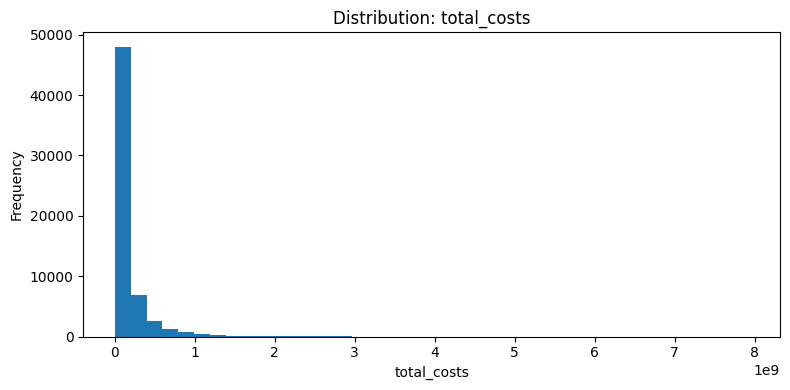

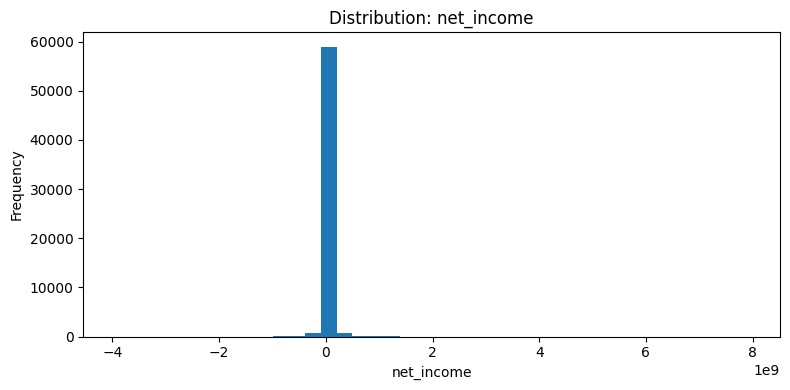

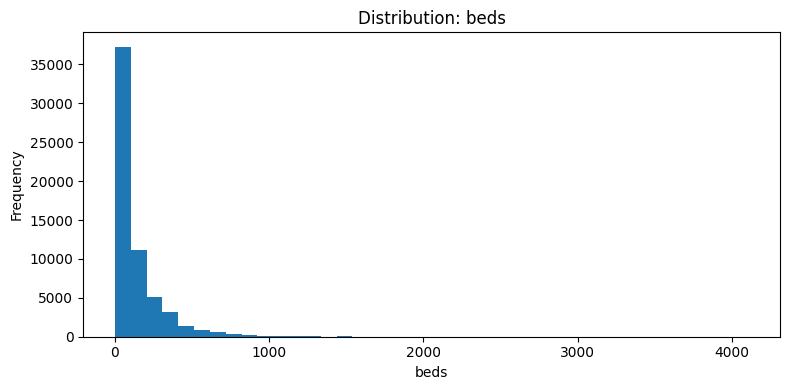

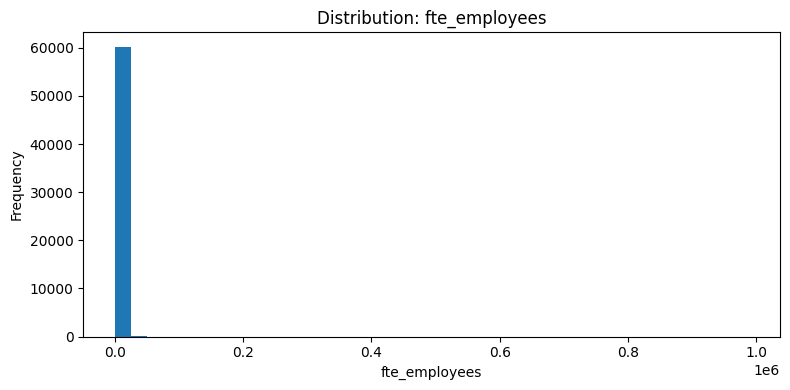

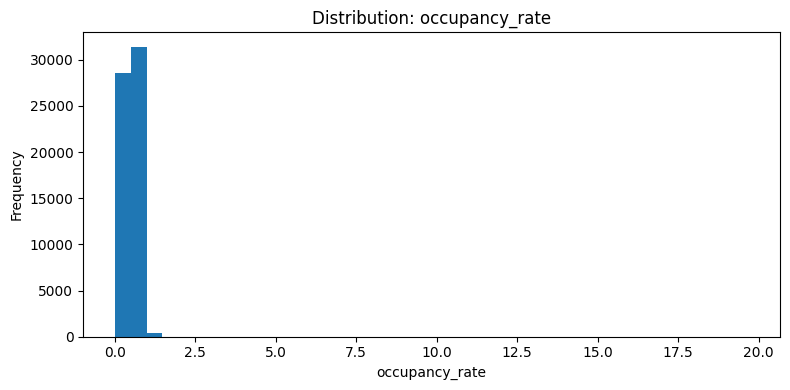

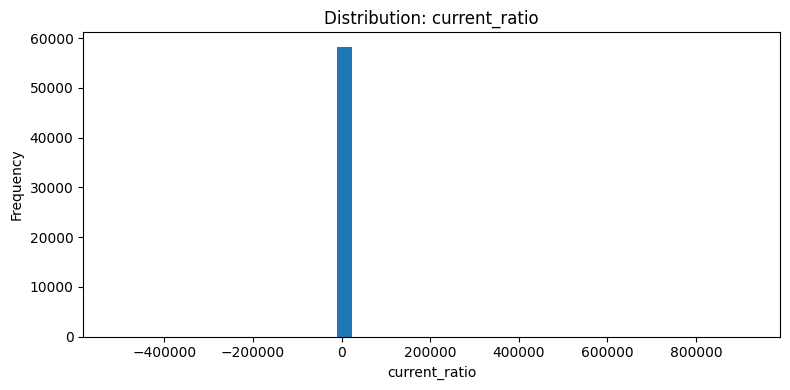

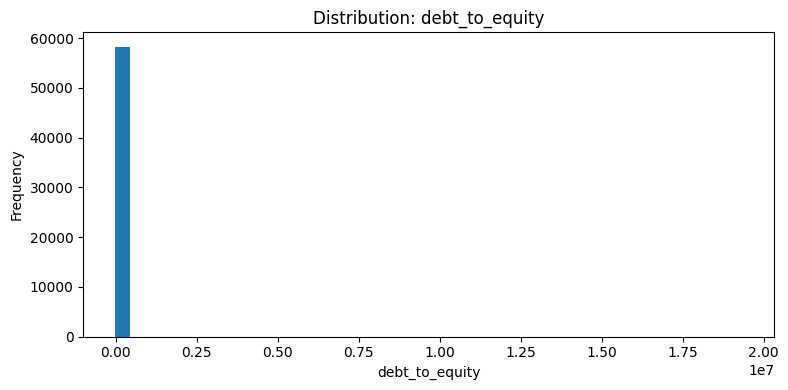

In [ ]:
selected_numeric = [c for c in [
    "net_patient_revenue",
    "total_costs",
    "net_income",
    "beds",
    "fte_employees",
    "occupancy_rate",
    "current_ratio",
    "debt_to_equity"
] if c in df.columns]

for col in selected_numeric:
    series = df[col].dropna()
    if series.empty:
        continue
    plt.figure(figsize=(8, 4))
    plt.hist(series, bins=40)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## 7. Time trends for selected measures

,total_costs,net_income,beds,fte_employees
report_year,,,,
2014,38353139.0,1560673.0,67.0,294.520
2015,39854831.0,1350827.5,65.0,292.370
2016,41893513.5,1259610.5,66.0,298.710
2017,43088271.5,1238204.5,66.0,302.205
2018,44615503.0,1203824.5,66.0,300.610
2019,45684880.0,1576250.0,66.0,293.620
2020,47320763.0,3700390.0,64.0,293.875
2021,52116149.0,3145640.0,65.0,291.370
2022,54352147.0,750973.0,64.0,288.250


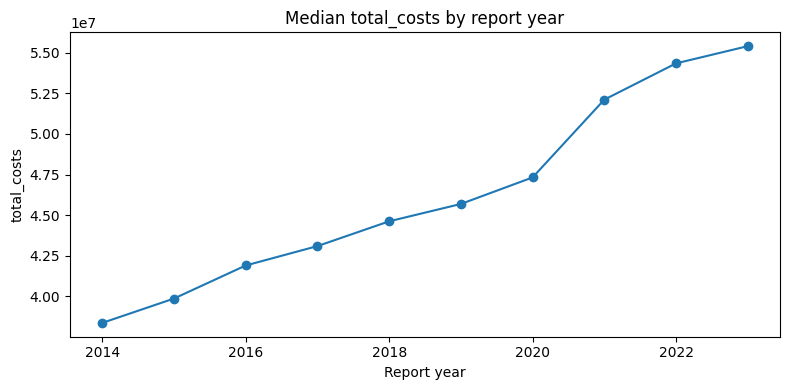

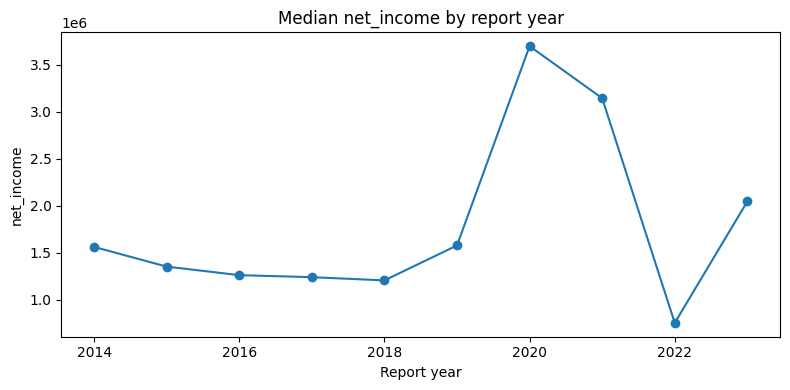

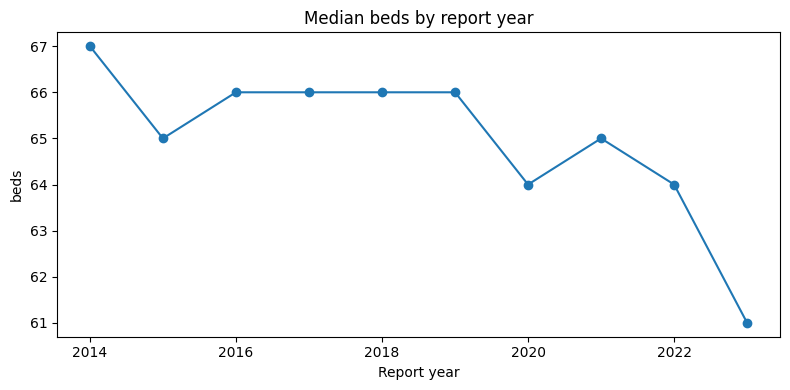

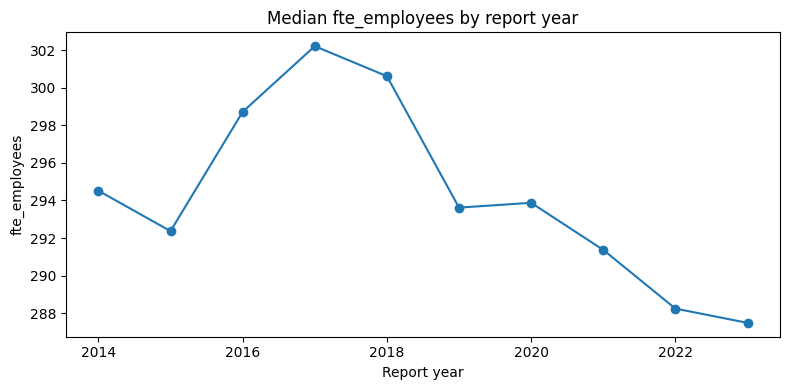

In [ ]:
trend_cols = [c for c in ["net_patient_revenue", "total_costs", "net_income", "beds", "fte_employees"] if c in df.columns]
if "report_year" in df.columns and trend_cols:
    yearly_medians = df.groupby("report_year")[trend_cols].median()
    display(yearly_medians)

    for col in trend_cols:
        plt.figure(figsize=(8, 4))
        plt.plot(yearly_medians.index, yearly_medians[col], marker="o")
        plt.title(f"Median {col} by report year")
        plt.xlabel("Report year")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


## 8. Ransomware vs. non-ransomware comparison

In [ ]:
compare_cols = [c for c in [
    "net_patient_revenue",
    "total_costs",
    "net_income",
    "beds",
    "fte_employees",
    "occupancy_rate",
    "current_ratio",
    "debt_to_equity",
    "net_profit_margin",
    "operating_margin"
] if c in df.columns]

if "had_ransomware" in df.columns:
    grp_median = df.groupby("had_ransomware")[compare_cols].median().T
    grp_mean = df.groupby("had_ransomware")[compare_cols].mean().T
    display(grp_median)
    display(grp_mean)


had_ransomware,0,1
total_costs,4.458633e+07,1.273261e+08
net_income,1.702570e+06,4.535218e+06
beds,6.400000e+01,1.280000e+02
fte_employees,2.860000e+02,9.060700e+02
occupancy_rate,5.130691e-01,5.263848e-01
current_ratio,1.839528e+00,2.118757e+00
debt_to_equity,4.071871e-01,6.775271e-01
net_profit_margin,4.795189e-02,4.252756e-02
operating_margin,4.234985e-02,3.810057e-02


had_ransomware,0,1
total_costs,1.421850e+08,3.942482e+08
net_income,9.279850e+06,3.400178e+07
beds,1.290222e+02,2.478864e+02
fte_employees,9.038474e+02,2.361273e+03
occupancy_rate,5.037546e-01,5.172127e-01
current_ratio,5.317262e+01,2.699744e+00
debt_to_equity,3.430253e+02,5.232549e+00
net_profit_margin,-9.787948e+02,4.345317e-02
operating_margin,3.222098e-02,3.542355e-02


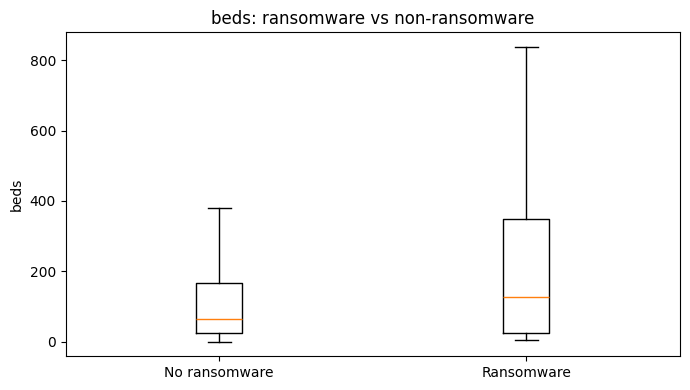

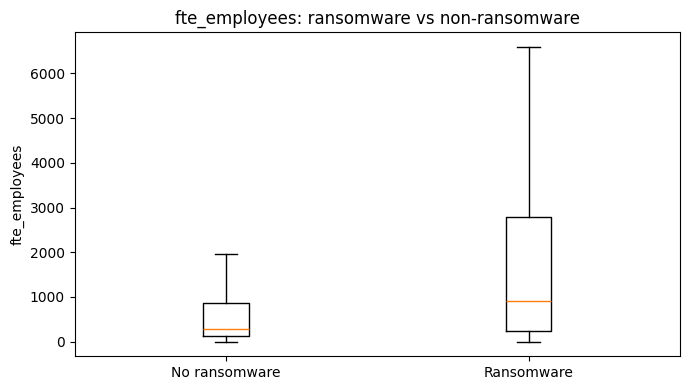

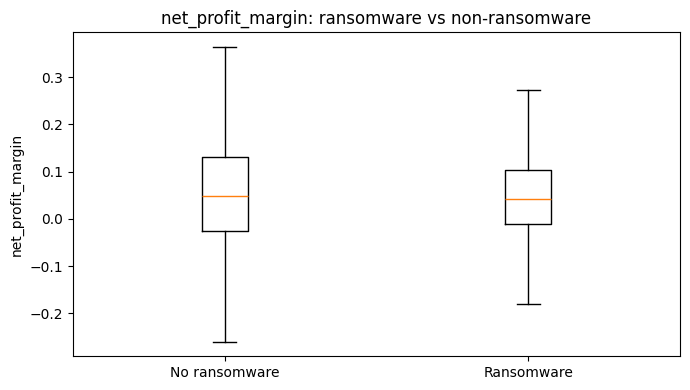

In [ ]:
if "had_ransomware" in df.columns:
    for col in [c for c in ["beds", "fte_employees", "net_patient_revenue", "net_profit_margin"] if c in df.columns]:
        grouped = [
            df.loc[df["had_ransomware"] == 0, col].dropna(),
            df.loc[df["had_ransomware"] == 1, col].dropna()
        ]
        plt.figure(figsize=(7, 4))
        plt.boxplot(grouped, tick_labels=["No ransomware", "Ransomware"], showfliers=False)
        plt.title(f"{col}: ransomware vs non-ransomware")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


## 9. Correlation review

,total_costs,net_income,beds,fte_employees,occupancy_rate,current_ratio,debt_to_equity,asset_turnover,liability_ratio,net_profit_margin,operating_margin,had_ransomware
total_costs,1.000,0.316,0.836,0.182,0.316,-0.002,-0.001,0.005,-0.003,0.002,0.035,0.146
net_income,0.316,1.000,0.274,0.056,0.104,0.000,-0.001,0.010,-0.002,-0.005,0.425,0.048
beds,0.836,0.274,1.000,0.163,0.346,-0.003,0.002,0.006,-0.004,0.006,0.020,0.116
fte_employees,0.182,0.056,0.163,1.000,0.078,-0.001,-0.001,0.001,-0.002,0.001,-0.031,0.032
occupancy_rate,0.316,0.104,0.346,0.078,1.000,0.002,-0.004,0.009,-0.011,-0.002,0.040,0.008
current_ratio,-0.002,0.000,-0.003,-0.001,0.002,1.000,-0.000,-0.000,-0.000,-0.000,0.004,-0.002
debt_to_equity,-0.001,-0.001,0.002,-0.001,-0.004,-0.000,1.000,-0.000,-0.000,-0.000,-0.002,-0.001
asset_turnover,0.005,0.010,0.006,0.001,0.009,-0.000,-0.000,1.000,0.035,-0.000,0.006,-0.002
liability_ratio,-0.003,-0.002,-0.004,-0.002,-0.011,-0.000,-0.000,0.035,1.000,-0.000,-0.007,-0.001
net_profit_margin,0.002,-0.005,0.006,0.001,-0.002,-0.000,-0.000,-0.000,-0.000,1.000,0.003,0.000


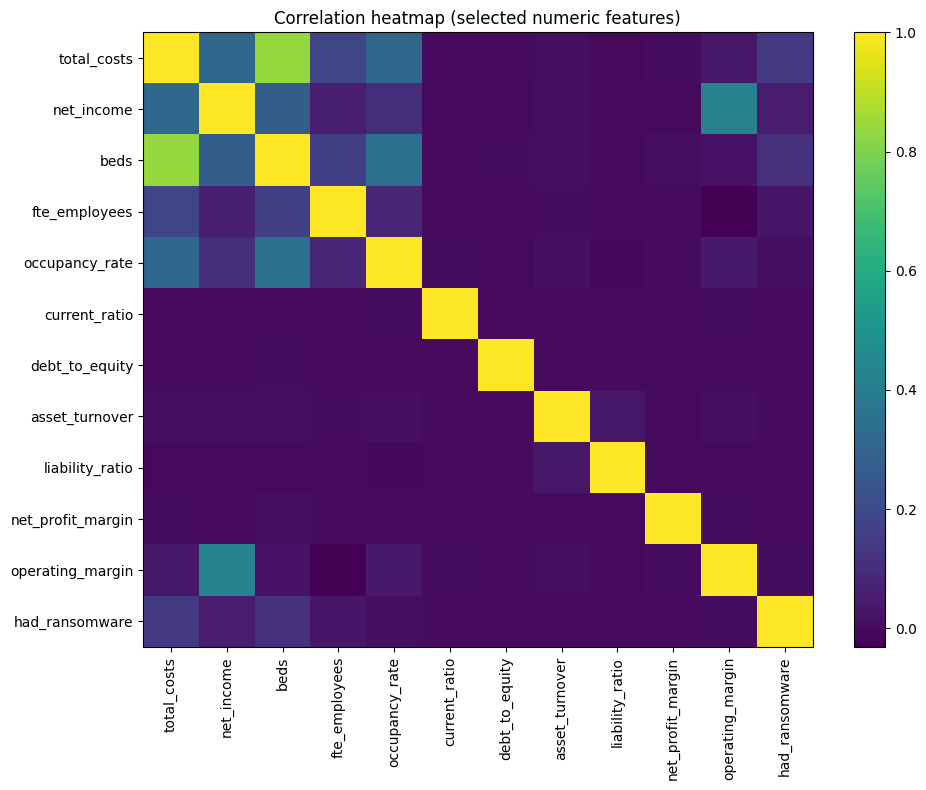

,corr_with_had_ransomware
had_ransomware,1.000000
total_costs,0.145788
beds,0.115679
net_income,0.047899
fte_employees,0.031640
occupancy_rate,0.008499
asset_turnover,-0.002345
current_ratio,-0.001528
operating_margin,0.001520
liability_ratio,-0.001422


In [ ]:
corr_cols = [c for c in [
    "net_patient_revenue",
    "total_costs",
    "net_income",
    "beds",
    "fte_employees",
    "occupancy_rate",
    "current_ratio",
    "debt_to_equity",
    "asset_turnover",
    "equity_ratio",
    "liability_ratio",
    "net_profit_margin",
    "operating_margin",
    "had_ransomware",
    "had_breach"
] if c in df.columns]

corr = df[corr_cols].corr(numeric_only=True)
display(corr.round(3))

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap (selected numeric features)")
plt.tight_layout()
plt.show()

if "had_ransomware" in corr.columns:
    ransomware_corr = corr["had_ransomware"].sort_values(key=lambda s: s.abs(), ascending=False)
    display(ransomware_corr.to_frame("corr_with_had_ransomware"))


## 10. Modeling-readiness checks

In [ ]:
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
high_missing_cols = missing.loc[missing["missing_pct"] > 50, "column"].tolist()

readiness = {
    "constant_or_single_value_columns": constant_cols,
    "columns_above_50pct_missing": high_missing_cols[:50],
    "count_columns_above_50pct_missing": len(high_missing_cols)
}
readiness


{'constant_or_single_value_columns': [],
 'columns_above_50pct_missing': ['hospital_rating'],
 'count_columns_above_50pct_missing': 1}

In [ ]:
candidate_ids = [c for c in ["ccn", "cbsa", "report_year", "first_breach_year", "last_breach_year"] if c in df.columns]
cardinality = pd.DataFrame({
    "column": candidate_ids,
    "nunique": [df[c].nunique(dropna=True) for c in candidate_ids],
    "missing_pct": [df[c].isna().mean() * 100 for c in candidate_ids]
})
display(cardinality)


,column,nunique,missing_pct
0,ccn,6804,0.000000
1,cbsa,597,1.267821
2,report_year,10,0.000000


## Code for Figures and tables for article


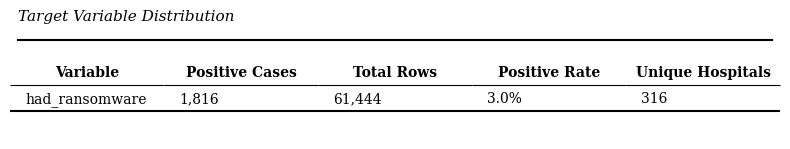

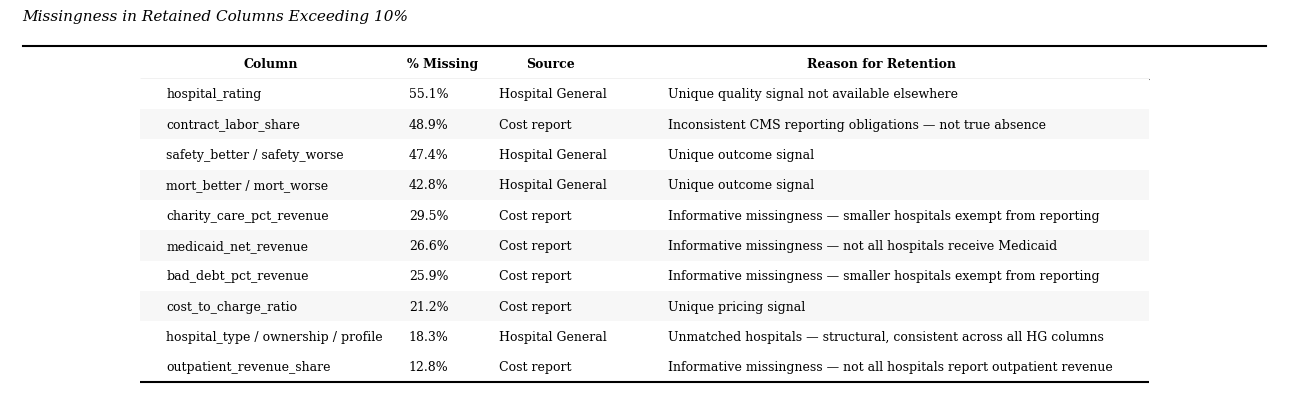

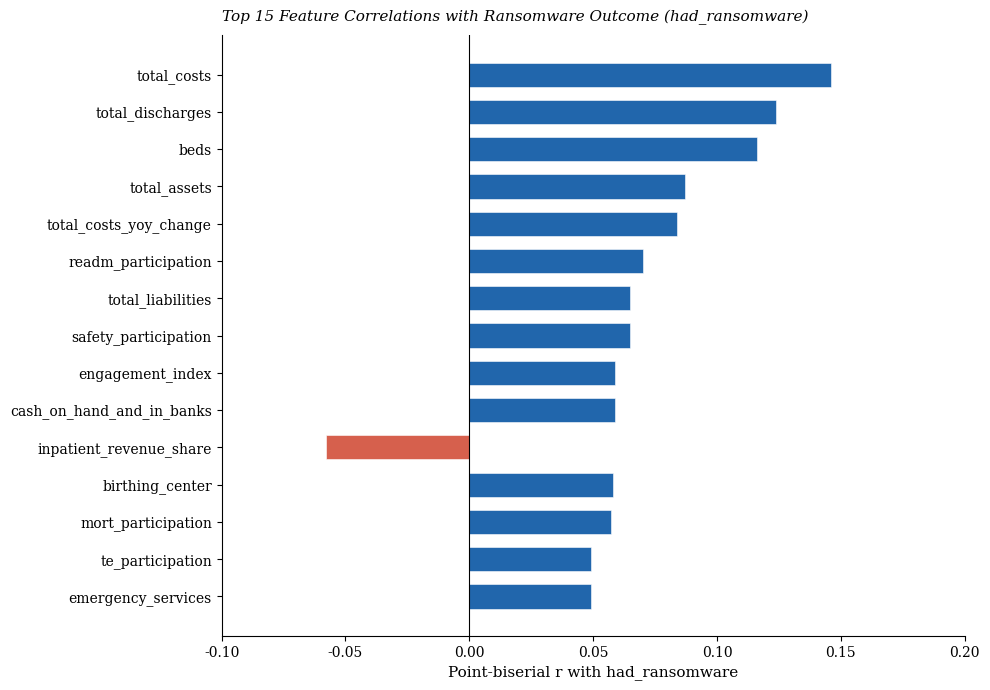

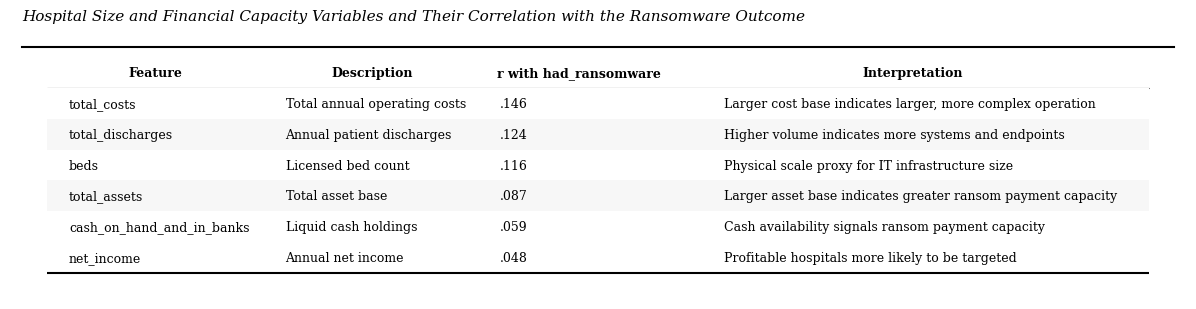

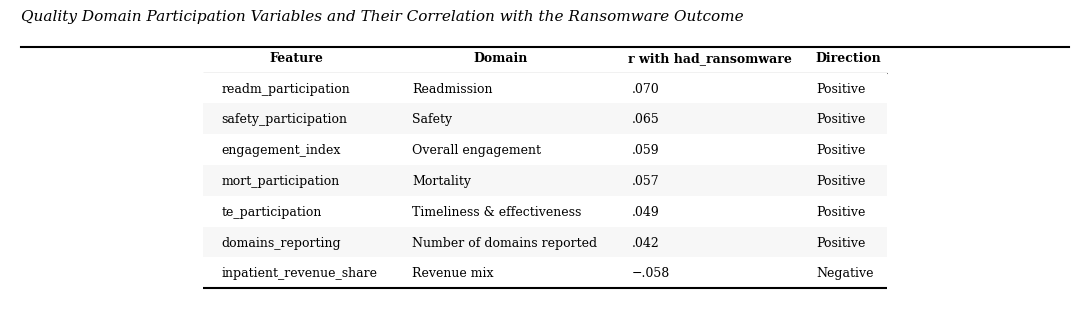

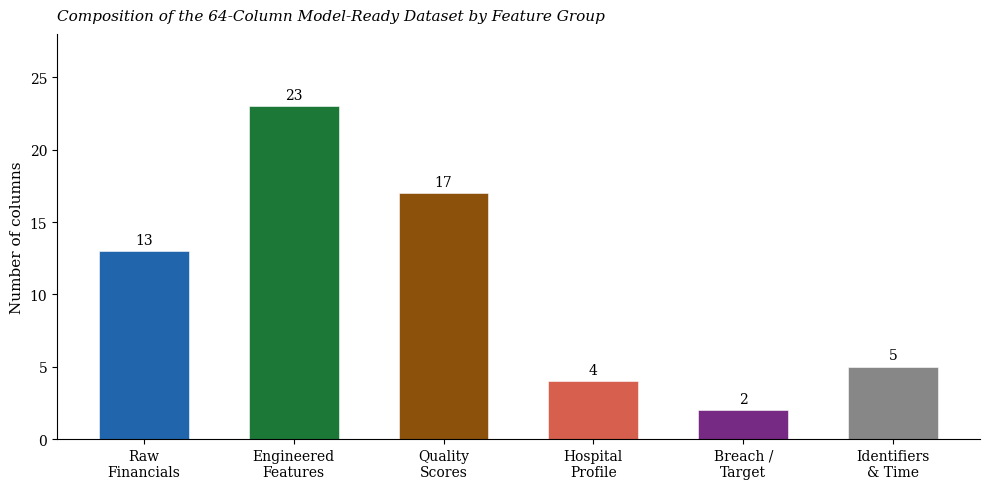

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# ── shared style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'serif',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.linewidth'   : 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
})

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 1 — Target Variable Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 1.6))
ax.axis('off')

headers = ['Variable', 'Positive Cases', 'Total Rows', 'Positive Rate', 'Unique Hospitals']
rows    = [['had_ransomware', '1,816', '61,444', '3.0%', '316']]

table = ax.table(
    cellText=rows,
    colLabels=headers,
    loc='center',
    cellLoc='left',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# APA-style: thick top and bottom, thin header bottom
for (r, c), cell in table.get_celld().items():
    cell.set_linewidth(0)
    if r == 0:
        cell.set_text_props(fontweight='bold')
        cell.set_edgecolor('black')
        cell.visible_edges = 'B'
        cell.set_linewidth(0.8)
    if r == len(rows):
        cell.visible_edges = 'B'
        cell.set_linewidth(1.5)

# top rule
ax.axhline(y=0.92, xmin=0.01, xmax=0.99, color='black', linewidth=1.5)

ax.set_title('Target Variable Distribution',
             fontsize=11, loc='left', pad=8, fontweight='normal',
             fontstyle='italic', x=0.01)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 2 — Missingness in Retained Columns Exceeding 10%
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.axis('off')

headers = ['Column', '% Missing', 'Source', 'Reason for Retention']
rows = [
    ['hospital_rating',                  '55.1%', 'Hospital General', 'Unique quality signal not available elsewhere'],
    ['contract_labor_share',             '48.9%', 'Cost report',      'Inconsistent CMS reporting obligations — not true absence'],
    ['safety_better / safety_worse',     '47.4%', 'Hospital General', 'Unique outcome signal'],
    ['mort_better / mort_worse',         '42.8%', 'Hospital General', 'Unique outcome signal'],
    ['charity_care_pct_revenue',         '29.5%', 'Cost report',      'Informative missingness — smaller hospitals exempt from reporting'],
    ['medicaid_net_revenue',             '26.6%', 'Cost report',      'Informative missingness — not all hospitals receive Medicaid'],
    ['bad_debt_pct_revenue',             '25.9%', 'Cost report',      'Informative missingness — smaller hospitals exempt from reporting'],
    ['cost_to_charge_ratio',             '21.2%', 'Cost report',      'Unique pricing signal'],
    ['hospital_type / ownership / profile','18.3%','Hospital General','Unmatched hospitals — structural, consistent across all HG columns'],
    ['outpatient_revenue_share',         '12.8%', 'Cost report',      'Informative missingness — not all hospitals report outpatient revenue'],
]

table = ax.table(cellText=rows, colLabels=headers, loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)
table.auto_set_column_width([0, 1, 2, 3])

for (r, c), cell in table.get_celld().items():
    cell.set_linewidth(0)
    if r == 0:
        cell.set_text_props(fontweight='bold')
        cell.visible_edges = 'B'
        cell.set_linewidth(0.8)
    if r == len(rows):
        cell.visible_edges = 'B'
        cell.set_linewidth(1.5)
    if r % 2 == 0 and r > 0:
        cell.set_facecolor('#f7f7f7')

ax.axhline(y=0.96, xmin=0.01, xmax=0.99, color='black', linewidth=1.5)

ax.set_title('Missingness in Retained Columns Exceeding 10%',
             fontsize=11, loc='left', pad=8, fontweight='normal',
             fontstyle='italic', x=0.01)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Top 15 Correlations with had_ransomware
# ══════════════════════════════════════════════════════════════════════════════
labels = [
    'total_costs', 'total_discharges', 'beds', 'total_assets',
    'total_costs_yoy_change', 'readm_participation', 'total_liabilities',
    'safety_participation', 'engagement_index', 'cash_on_hand_and_in_banks',
    'inpatient_revenue_share', 'birthing_center', 'mort_participation',
    'te_participation', 'emergency_services',
]
vals   = [0.146, 0.124, 0.116, 0.087, 0.084, 0.070, 0.065, 0.065,
          0.059, 0.059, -0.058, 0.058, 0.057, 0.049, 0.049]
colors = ['#2166ac' if v >= 0 else '#d6604d' for v in vals]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(labels[::-1], vals[::-1], color=colors[::-1],
        edgecolor='white', linewidth=0.4, height=0.65)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-biserial r with had_ransomware', fontsize=11)
ax.set_xlim(-0.10, 0.20)
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
ax.tick_params(axis='both', labelsize=10)
ax.set_title('Top 15 Feature Correlations with Ransomware Outcome (had_ransomware)',
             fontsize=11, loc='left', pad=10, fontweight='normal', fontstyle='italic')

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 3 — Hospital Size Variables and Correlations
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.axis('off')

headers = ['Feature', 'Description', 'r with had_ransomware', 'Interpretation']
rows = [
    ['total_costs',              'Total annual operating costs',  '.146', 'Larger cost base indicates larger, more complex operation'],
    ['total_discharges',         'Annual patient discharges',     '.124', 'Higher volume indicates more systems and endpoints'],
    ['beds',                     'Licensed bed count',            '.116', 'Physical scale proxy for IT infrastructure size'],
    ['total_assets',             'Total asset base',              '.087', 'Larger asset base indicates greater ransom payment capacity'],
    ['cash_on_hand_and_in_banks','Liquid cash holdings',          '.059', 'Cash availability signals ransom payment capacity'],
    ['net_income',               'Annual net income',             '.048', 'Profitable hospitals more likely to be targeted'],
]

table = ax.table(cellText=rows, colLabels=headers, loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.7)
table.auto_set_column_width([0, 1, 2, 3])

for (r, c), cell in table.get_celld().items():
    cell.set_linewidth(0)
    if r == 0:
        cell.set_text_props(fontweight='bold')
        cell.visible_edges = 'B'
        cell.set_linewidth(0.8)
    if r == len(rows):
        cell.visible_edges = 'B'
        cell.set_linewidth(1.5)
    if r % 2 == 0 and r > 0:
        cell.set_facecolor('#f7f7f7')

ax.axhline(y=0.94, xmin=0.01, xmax=0.99, color='black', linewidth=1.5)

ax.set_title('Hospital Size and Financial Capacity Variables and Their Correlation with the Ransomware Outcome',
             fontsize=11, loc='left', pad=8, fontweight='normal',
             fontstyle='italic', x=0.01)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 4 — Quality Domain Participation Correlations
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis('off')

headers = ['Feature', 'Domain', 'r with had_ransomware', 'Direction']
rows = [
    ['readm_participation',   'Readmission',              '.070',  'Positive'],
    ['safety_participation',  'Safety',                   '.065',  'Positive'],
    ['engagement_index',      'Overall engagement',       '.059',  'Positive'],
    ['mort_participation',    'Mortality',                '.057',  'Positive'],
    ['te_participation',      'Timeliness & effectiveness','.049', 'Positive'],
    ['domains_reporting',     'Number of domains reported','.042', 'Positive'],
    ['inpatient_revenue_share','Revenue mix',             '−.058', 'Negative'],
]

table = ax.table(cellText=rows, colLabels=headers, loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.7)
table.auto_set_column_width([0, 1, 2, 3])

for (r, c), cell in table.get_celld().items():
    cell.set_linewidth(0)
    if r == 0:
        cell.set_text_props(fontweight='bold')
        cell.visible_edges = 'B'
        cell.set_linewidth(0.8)
    if r == len(rows):
        cell.visible_edges = 'B'
        cell.set_linewidth(1.5)
    if r % 2 == 0 and r > 0:
        cell.set_facecolor('#f7f7f7')

ax.axhline(y=0.94, xmin=0.01, xmax=0.99, color='black', linewidth=1.5)

ax.set_title('Quality Domain Participation Variables and Their Correlation with the Ransomware Outcome',
             fontsize=11, loc='left', pad=8, fontweight='normal',
             fontstyle='italic', x=0.01)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Dataset Composition Grouped Bar
# ══════════════════════════════════════════════════════════════════════════════
groups = ['Raw\nFinancials', 'Engineered\nFeatures', 'Quality\nScores',
          'Hospital\nProfile', 'Breach /\nTarget', 'Identifiers\n& Time']
counts = [13, 23, 17, 4, 2, 5]
colors_bar = ['#2166ac', '#1b7837', '#8c510a', '#d6604d', '#762a83', '#878787']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(groups, counts, color=colors_bar,
              edgecolor='white', linewidth=0.4, width=0.6)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of columns', fontsize=11)
ax.set_ylim(0, 28)
ax.tick_params(axis='both', labelsize=10)
ax.set_title('Composition of the 64-Column Model-Ready Dataset by Feature Group',
             fontsize=11, loc='left', pad=10, fontweight='normal', fontstyle='italic')

plt.tight_layout()
plt.show()

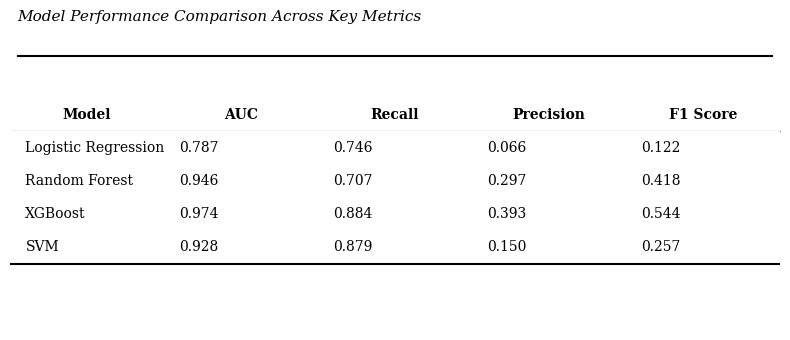

In [ ]:
import matplotlib.pyplot as plt

# ── shared style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'serif',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.linewidth'   : 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
})

# ══════════════════════════════════════════════════════════════════════════════
# New Table: Model Performance Comparison Across Key Metrics
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 3.5)) # Adjusted figsize for better display
ax.axis('off')

headers = ['Model', 'AUC', 'Recall', 'Precision', 'F1 Score']
rows = [
    ['Logistic Regression', '0.787', '0.746', '0.066', '0.122'],
    ['Random Forest', '0.946', '0.707', '0.297', '0.418'],
    ['XGBoost', '0.974', '0.884', '0.393', '0.544'],
    ['SVM', '0.928', '0.879', '0.150', '0.257'],
]

table = ax.table(
    cellText=rows,
    colLabels=headers,
    loc='center',
    cellLoc='left',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# APA-style: thick top and bottom, thin header bottom
for (r, c), cell in table.get_celld().items():
    cell.set_linewidth(0)
    if r == 0: # Header row
        cell.set_text_props(fontweight='bold')
        cell.set_edgecolor('black')
        cell.visible_edges = 'B'
        cell.set_linewidth(0.8)
    if r == len(rows): # Bottom row
        cell.visible_edges = 'B'
        cell.set_linewidth(1.5)

# Top rule for the table
ax.axhline(y=0.92, xmin=0.01, xmax=0.99, color='black', linewidth=1.5)

ax.set_title('Model Performance Comparison Across Key Metrics',
             fontsize=11, loc='left', pad=8, fontweight='normal',
             fontstyle='italic', x=0.01)

plt.tight_layout()
plt.show()